In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Make plots look nicer
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [7]:
#1. LOAD DATA
file_path = "Airline_Delay_Cause.csv"

df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print("First 5 rows:")
display(df.head())


Original shape: (398233, 21)
First 5 rows:


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,1.60,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,0.00,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,2.83,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [9]:
# 2. STANDARDIZE COLUMN NAMES (lowercase, no spaces)
df.columns = [c.strip().lower() for c in df.columns]
print("\nColumns after lowercasing:")
print(df.columns.tolist())



Columns after lowercasing:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [11]:
# 3. BASIC EXPLORATION
# ------------------------------------------------------------

print("\n--- INFO ---")
print(df.info())

print("\n--- DESCRIPTIVE STATISTICS (NUMERIC) ---")
display(df.describe().T)

print("\n--- MISSING VALUES PER COLUMN ---")
display(df.isna().sum())



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398233 entries, 0 to 398232
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 398233 non-null  int64  
 1   month                398233 non-null  int64  
 2   carrier              398233 non-null  object 
 3   carrier_name         398233 non-null  object 
 4   airport              398233 non-null  object 
 5   airport_name         398233 non-null  object 
 6   arr_flights          397576 non-null  float64
 7   arr_del15            397283 non-null  float64
 8   carrier_ct           397576 non-null  float64
 9   weather_ct           397576 non-null  float64
 10  nas_ct               397576 non-null  float64
 11  security_ct          397576 non-null  float64
 12  late_aircraft_ct     397576 non-null  float64
 13  arr_cancelled        397576 non-null  float64
 14  arr_diverted         397576 non-null  float64
 15  arr

,count,mean,std,min,25%,50%,75%,max
year,398233.0,2014.421344,6.474505,2003.00,2009.00,2015.00,2020.00,2025.00
month,398233.0,6.524078,3.463111,1.00,4.00,7.00,10.00,12.00
arr_flights,397576.0,361.663536,993.947394,1.00,56.00,113.00,255.00,21977.00
arr_del15,397283.0,69.593947,193.608821,0.00,8.00,21.00,52.00,6377.00
carrier_ct,397576.0,20.540331,48.314208,0.00,2.79,7.51,18.65,1886.58
weather_ct,397576.0,2.508231,9.570840,0.00,0.00,0.51,2.00,717.94
nas_ct,397576.0,22.209529,79.473052,-0.01,1.40,4.91,13.99,4091.27
security_ct,397576.0,0.172630,0.826248,0.00,0.00,0.00,0.00,80.56
late_aircraft_ct,397576.0,24.111972,74.414722,0.00,1.51,5.49,16.15,2588.13
arr_cancelled,397576.0,6.789323,35.086108,0.00,0.00,1.00,4.00,4951.00



--- MISSING VALUES PER COLUMN ---


year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            657
arr_del15              950
carrier_ct             657
weather_ct             657
nas_ct                 657
security_ct            657
late_aircraft_ct       657
arr_cancelled          657
arr_diverted           657
arr_delay              657
carrier_delay          657
weather_delay          657
nas_delay              657
security_delay         657
late_aircraft_delay    657
dtype: int64

In [13]:
# 4. DATA CLEANING / PREPARATION
# ------------------------------------------------------------

# 4.1 Keep only rows with valid year, month, carrier, airport
required_cols = ["year", "month", "carrier", "airport"]
missing_req = [c for c in required_cols if c not in df.columns]
if missing_req:
    print("\nWARNING: These required columns are missing:", missing_req)
else:
    df = df.dropna(subset=required_cols)

In [15]:
# 4.2 Define delay-related numeric columns (some may not exist depending on version)
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
]

existing_delay_cols = [c for c in delay_cols if c in df.columns]
print("\nDelay columns found:", existing_delay_cols)

# If any delay column is missing, just fill it with 0 (for safe total calculation)
for c in delay_cols:
    if c not in df.columns:
        df[c] = 0.0



Delay columns found: ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [17]:
# 4.3 Ensure all delay columns are numeric and no negatives
df[delay_cols] = df[delay_cols].apply(pd.to_numeric, errors="coerce")
df[delay_cols] = df[delay_cols].fillna(0)
df[delay_cols] = df[delay_cols].clip(lower=0)

In [19]:
# 4.4 Create TOTAL DELAY column (sum of all causes)
df["total_delay"] = df[delay_cols].sum(axis=1)


In [21]:
# 4.5 Make month name & year-month for easier plots
if "month" in df.columns:
    month_map = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
    }
    df["month_name"] = df["month"].map(month_map)

if {"year", "month"}.issubset(df.columns):
    df["year_month"] = pd.to_datetime(
        df["year"].astype(int).astype(str) + "-" +
        df["month"].astype(int).astype(str) + "-01"
    )

print("\nCleaned shape:", df.shape)
display(df.head())


Cleaned shape: (398233, 24)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay,month_name,year_month
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Jan,2025-01-01
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Jan,2025-01-01
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,1.60,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0,409.0,Jan,2025-01-01
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,0.00,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0,1075.0,Jan,2025-01-01
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,2.83,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0,446.0,Jan,2025-01-01


In [23]:
# 5. OVERALL SUMMARY & TOP-LEVEL METRICS
# ------------------------------------------------------------

print("\n--- OVERALL AVERAGE DELAY BY CAUSE (MINUTES PER RECORD) ---")
avg_delay_by_cause = df[delay_cols].mean().sort_values(ascending=False)
display(avg_delay_by_cause)

print("\n--- AVERAGE TOTAL DELAY BY CARRIER ---")
if "carrier" in df.columns:
    avg_delay_by_carrier = (
        df.groupby("carrier")["total_delay"]
        .mean()
        .sort_values(ascending=False)
    )
    display(avg_delay_by_carrier)


--- OVERALL AVERAGE DELAY BY CAUSE (MINUTES PER RECORD) ---


late_aircraft_delay    1599.025249
carrier_delay          1307.157081
nas_delay              1024.319230
weather_delay           222.962615
security_delay            7.132551
dtype: float64


--- AVERAGE TOTAL DELAY BY CARRIER ---


carrier
WN    11412.402001
AA     8850.779030
UA     6209.373380
B6     5761.324247
NK     4947.887395
DL     4875.082503
US     4515.663208
CO     4337.141246
XE     3950.417898
FL     3926.104370
NW     3657.256309
DH     3655.746362
EV     3521.250233
VX     3428.238095
RU     3391.700919
OO     3381.921449
MQ     3132.321418
YX     3062.366080
CP     2922.450324
OH     2741.818105
HP     2709.768501
F9     2224.198711
TZ     2211.202381
YV     2182.481244
AS     2139.170428
C5     2018.993721
9E     1962.675949
AX     1939.406315
ZW     1672.294095
HA     1566.614081
PT     1530.706796
G7     1472.500220
EM     1430.187500
G4     1332.843217
KS     1314.113636
QX     1235.469181
AQ     1037.237154
9K      475.400000
Name: total_delay, dtype: float64

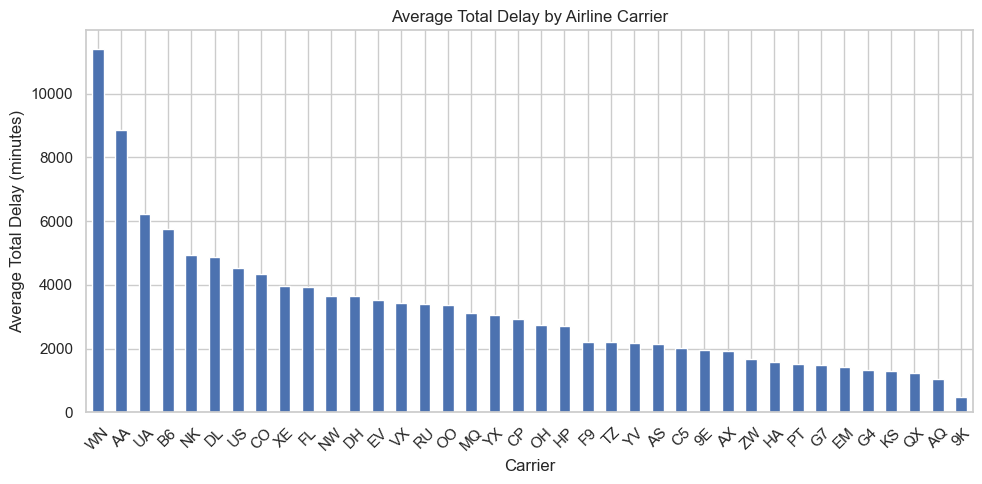

In [25]:
# 6. VISUALIZATION SECTION
# ------------------------------------------------------------

# 6.1 Average total delay by carrier
if "carrier" in df.columns:
    plt.figure(figsize=(10, 5))
    avg_delay_by_carrier.plot(kind="bar")
    plt.title("Average Total Delay by Airline Carrier")
    plt.xlabel("Carrier")
    plt.ylabel("Average Total Delay (minutes)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

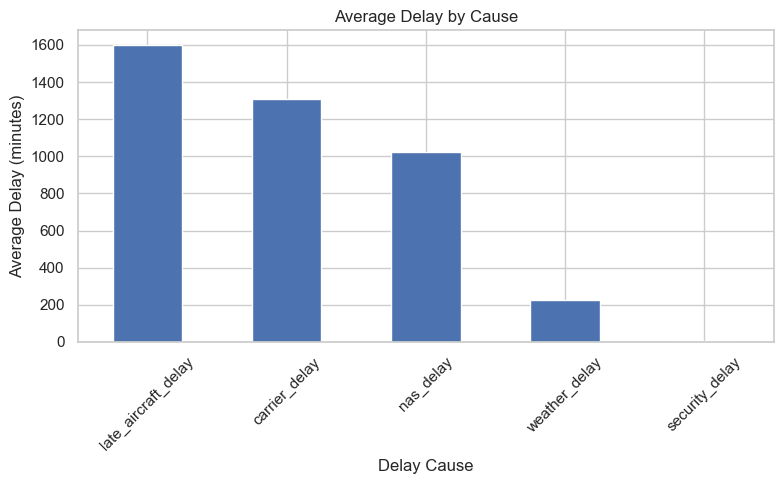

In [27]:
# 6.2 Average delay by cause (overall)
plt.figure(figsize=(8, 5))
avg_delay_by_cause.plot(kind="bar")
plt.title("Average Delay by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

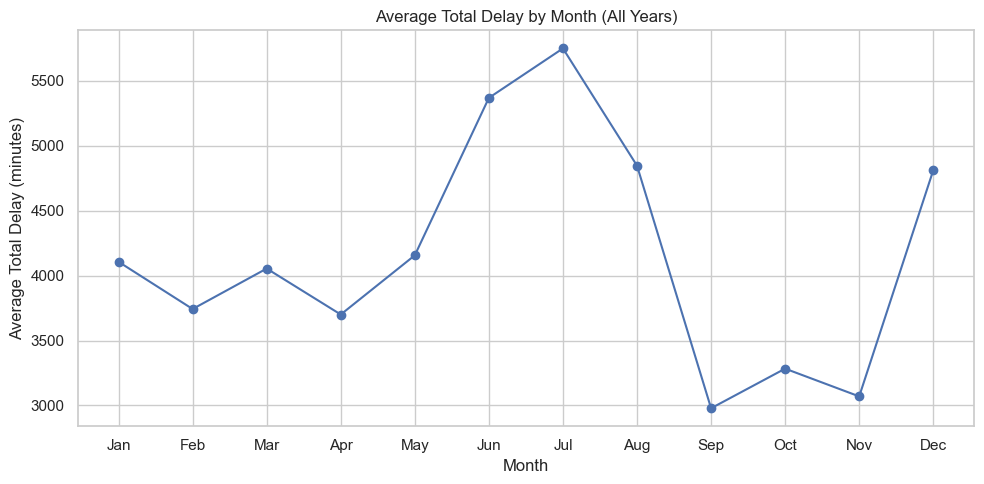

In [29]:
# 6.3 Monthly delay trend (average total delay per month across all years)
if "month_name" in df.columns:
    monthly_delay = (
        df.groupby("month_name")["total_delay"]
        .mean()
        .reindex(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    )

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_delay.index, monthly_delay.values, marker="o")
    plt.title("Average Total Delay by Month (All Years)")
    plt.xlabel("Month")
    plt.ylabel("Average Total Delay (minutes)")
    plt.tight_layout()
    plt.show()

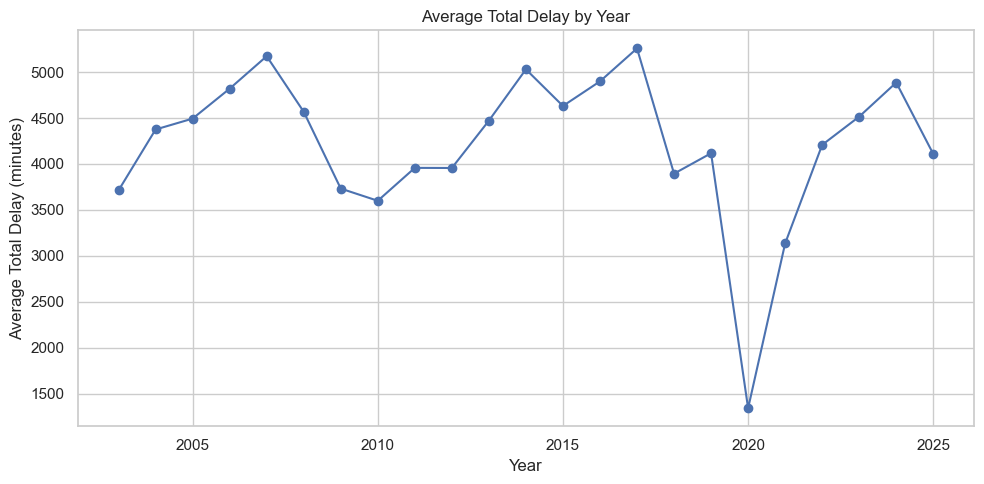

,year,total_delay
18,2021,3134.800877
19,2022,4207.654982
20,2023,4515.164847
21,2024,4886.062541
22,2025,4108.672756


In [31]:
# 6.4 Yearly delay trend (average total delay per year)
if "year" in df.columns:
    yearly_delay = (
        df.groupby("year")["total_delay"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    plt.plot(yearly_delay["year"], yearly_delay["total_delay"], marker="o")
    plt.title("Average Total Delay by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Total Delay (minutes)")
    plt.tight_layout()
    plt.show()
    display(yearly_delay.tail())

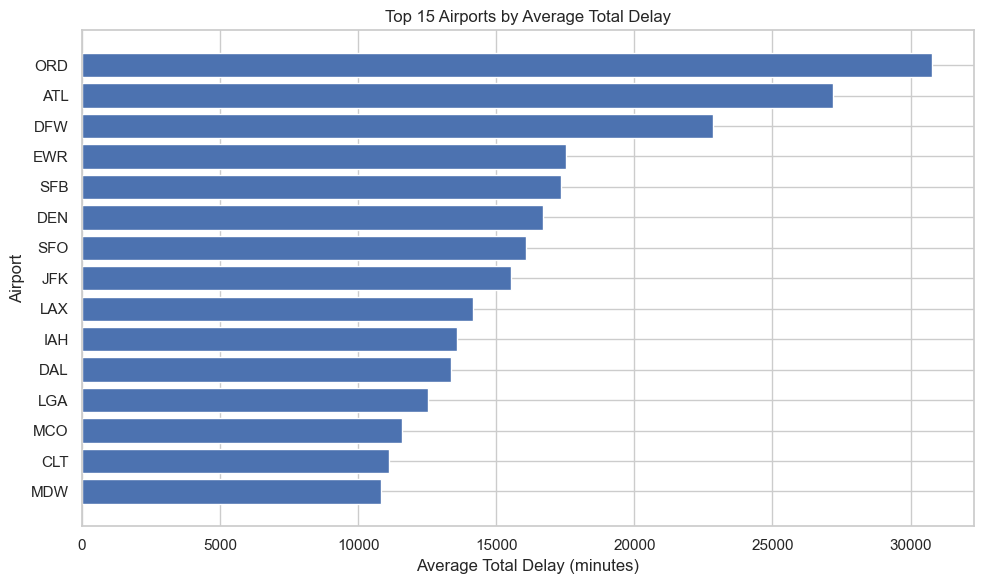


Top 5 most delayed airports:


airport
ORD    30757.083453
ATL    27207.548284
DFW    22831.511733
EWR    17518.151772
SFB    17339.247059
Name: total_delay, dtype: float64

In [33]:
# 6.5 Top 15 airports by average total delay
if "airport" in df.columns:
    airport_delay = (
        df.groupby("airport")["total_delay"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(airport_delay.index, airport_delay.values)
    plt.title("Top 15 Airports by Average Total Delay")
    plt.xlabel("Average Total Delay (minutes)")
    plt.ylabel("Airport")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("\nTop 5 most delayed airports:")
    display(airport_delay.head())

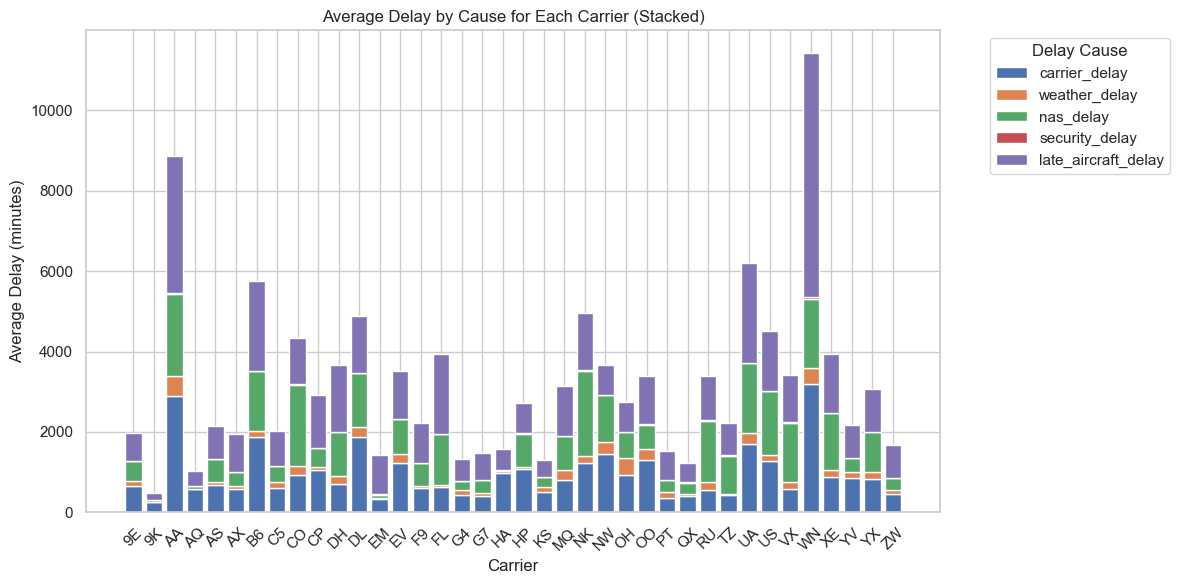

In [35]:
# 6.6 Stacked bar: delay cause distribution by carrier
if "carrier" in df.columns:
    avg_delays_by_carrier_cause = df.groupby("carrier")[delay_cols].mean()

    plt.figure(figsize=(12, 6))
    bottom = np.zeros(len(avg_delays_by_carrier_cause))
    x = np.arange(len(avg_delays_by_carrier_cause.index))

    for col in delay_cols:
        plt.bar(
            x,
            avg_delays_by_carrier_cause[col],
            bottom=bottom,
            label=col
        )
        bottom += avg_delays_by_carrier_cause[col].values

    plt.xticks(x, avg_delays_by_carrier_cause.index, rotation=45)
    plt.title("Average Delay by Cause for Each Carrier (Stacked)")
    plt.xlabel("Carrier")
    plt.ylabel("Average Delay (minutes)")
    plt.legend(title="Delay Cause", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

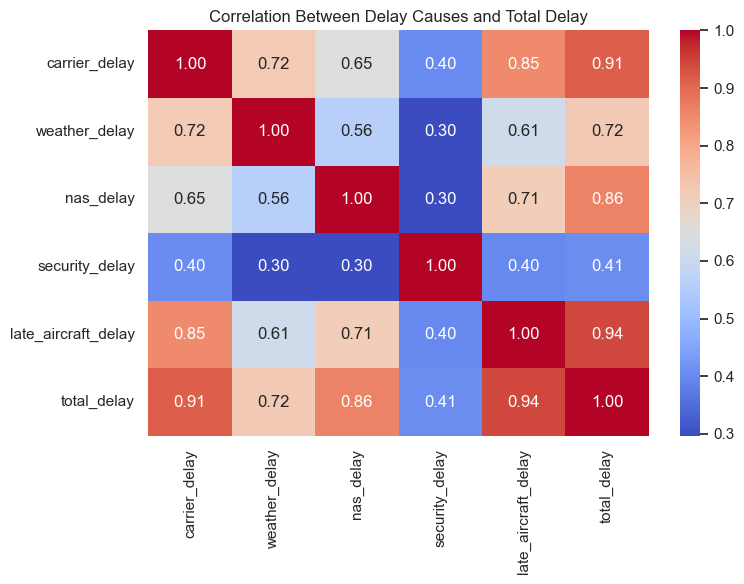


Correlation of each delay type with TOTAL DELAY:


total_delay            1.000000
late_aircraft_delay    0.944772
carrier_delay          0.914178
nas_delay              0.861196
weather_delay          0.723889
security_delay         0.405963
Name: total_delay, dtype: float64

In [37]:
# 7. CORRELATION ANALYSIS
# ------------------------------------------------------------

corr_cols = delay_cols + ["total_delay"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Delay Causes and Total Delay")
plt.tight_layout()
plt.show()

print("\nCorrelation of each delay type with TOTAL DELAY:")
display(corr["total_delay"].sort_values(ascending=False))
